# PROBLEMS
- Problem 1 — We're losing customers but we don't know who is most at risk. Can you identify what types of customers are churning and what they have in common?
- Problem 2 — There's a debate internally about whether our international plan and voicemail plan are actually worth it to customers, or if they're driving people away. Can you find out?
- Problem 3 — We think our customer service interactions might be making things worse. Can you investigate whether customers who call us more are more likely to leave?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Look into data

In [2]:
#read both files and save them into test and train df
train = pd.read_csv("churn-bigml-80.csv")
test = pd.read_csv("churn-bigml-20.csv")
train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [4]:
train['Area code'] = train['Area code'].astype('object')
train['Area code'].dtypes

dtype('O')

In [5]:
train.describe(include="all")

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
count,2666,2666.000000,2666.0,2666,2666,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666
unique,51,NaN,3.0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,WV,NaN,415.0,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,88,NaN,1318.0,2396,1933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2278
mean,NaN,100.620405,NaN,NaN,NaN,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641,NaN
std,NaN,39.563974,NaN,NaN,NaN,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236,NaN
min,NaN,1.000000,NaN,NaN,NaN,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,73.000000,NaN,NaN,NaN,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000,NaN
50%,NaN,100.000000,NaN,NaN,NaN,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000,NaN
75%,NaN,127.000000,NaN,NaN,NaN,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000,NaN


## Problem 1 — We're losing customers but we don't know who is most at risk. Can you identify what types of customers are churning and what they have in common?

In [6]:
#filter df to show only true churn
churned = train[train.Churn == True].copy()
no_churned = train[train.Churn == False].copy()
print(f"Shape of False Churn {no_churned.shape}")
print(f"Shape of True Churn {churned.shape}")

Shape of False Churn (2278, 20)
Shape of True Churn (388, 20)


### Find out how many customers are from which state, the number of customers in each area code, if customers have internal plans or not, and if they have voice mail plans or not in both dfs

#### Churned df

In [7]:
for cat in ['State', 'International plan', 'Voice mail plan', 'Area code']:
    print(f"Categorical variable statistics for people who churned: \n {churned[cat].value_counts(normalize = True) * 100}")

Categorical variable statistics for people who churned: 
 State
TX    4.123711
NJ    3.608247
MD    3.608247
MN    3.350515
NV    3.350515
MI    3.350515
NY    3.092784
ME    2.835052
AR    2.835052
SC    2.835052
MS    2.835052
CT    2.835052
KS    2.577320
WA    2.577320
MT    2.577320
OH    2.577320
NC    2.319588
NH    2.319588
WY    2.061856
MA    2.061856
GA    2.061856
DE    2.061856
PA    2.061856
UT    2.061856
OK    1.804124
FL    1.804124
OR    1.804124
CO    1.804124
AL    1.804124
WV    1.804124
SD    1.546392
IN    1.546392
VT    1.546392
KY    1.546392
DC    1.288660
ID    1.288660
MO    1.288660
TN    1.288660
CA    1.288660
ND    1.030928
IL    1.030928
VA    1.030928
WI    1.030928
NE    1.030928
NM    1.030928
AK    0.773196
AZ    0.773196
LA    0.773196
IA    0.773196
RI    0.773196
HI    0.515464
Name: proportion, dtype: float64
Categorical variable statistics for people who churned: 
 International plan
No     69.587629
Yes    30.412371
Name: proportion, dtype: fl

A lot of states have many customers that churned.70% of churned customers in the true churn dataframe have no international plan and 83% of churned customers have no voice mail plan. Looking at this we can assume that most customers that churn have no internal plan, no voice mail plan most of the time, and they are from certain states.

#### No_churned df

In [8]:
for cat in ['State', 'International plan', 'Voice mail plan', 'Area code']:
    print(f"Categorical variable statistics for people who didn't churn: \n {no_churned[cat].value_counts(normalize = True) * 100}")

Categorical variable statistics for people who didn't churn: 
 State
WV    3.555751
VA    2.765584
AL    2.589991
WY    2.546093
WI    2.502195
MN    2.502195
OH    2.458297
NY    2.458297
OR    2.414399
CO    2.282704
UT    2.282704
ID    2.238806
VT    2.238806
CT    2.107112
IN    2.107112
NV    2.107112
FL    2.063213
NC    2.063213
MO    2.019315
MD    2.019315
OK    1.975417
RI    1.975417
MI    1.975417
MA    1.931519
SD    1.887621
MT    1.887621
DE    1.887621
KS    1.843723
AZ    1.843723
HI    1.843723
NE    1.799824
IL    1.799824
GA    1.799824
DC    1.755926
ND    1.755926
AK    1.755926
NM    1.755926
TX    1.712028
WA    1.668130
SC    1.668130
ME    1.668130
KY    1.624232
MS    1.624232
TN    1.580334
NJ    1.580334
AR    1.580334
IA    1.536435
NH    1.492537
LA    1.404741
PA    1.229148
CA    0.834065
Name: proportion, dtype: float64
Categorical variable statistics for people who didn't churn: 
 International plan
No     93.32748
Yes     6.67252
Name: proportion, d

93% of non churned customers have no internation plan and 70% of non churned customers have no voice mail plan which means that most customers don't get international plans and voice mail plan.

In the dataframe with customers that churned, 30% have an international plan compared to only 6% of customers who did not churn, making churned customers approximately 4x more likely to hold an international plan. This suggests the international plan may be a contributing factor to churn, though it cannot be the sole driver as the majority of churned customers do not have the plan either.


### Look into the numerical variables of churned and non churned dataframe.

#### Statistical summary

In [9]:
churned.describe()

,Account length,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000
mean,102.319588,5.170103,205.181186,101.195876,34.881340,209.385309,99.948454,17.797861,205.307216,100.682990,9.238892,10.819330,4.051546,2.921727,2.206186
std,40.184599,11.876493,68.490213,21.705279,11.643479,50.863718,19.605474,4.323327,47.565157,20.074667,2.140617,2.771824,2.468912,0.748431,1.882536
min,1.000000,0.000000,0.000000,0.000000,0.000000,70.900000,48.000000,6.030000,47.400000,49.000000,2.130000,3.900000,1.000000,1.050000,0.000000
25%,75.750000,0.000000,150.900000,87.000000,25.652500,173.150000,86.000000,14.717500,169.925000,85.750000,7.647500,8.900000,2.000000,2.400000,1.000000
50%,103.000000,0.000000,214.950000,103.000000,36.540000,209.000000,100.500000,17.765000,204.950000,101.000000,9.225000,10.800000,3.000000,2.920000,2.000000
75%,127.000000,0.000000,262.200000,116.000000,44.577500,248.325000,113.000000,21.110000,241.150000,116.000000,10.852500,12.925000,5.000000,3.487500,4.000000
max,225.000000,45.000000,350.800000,156.000000,59.640000,363.700000,159.000000,30.910000,354.900000,158.000000,15.970000,20.000000,20.000000,5.400000,9.000000


In [10]:
no_churned.describe()

,Account length,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000
mean,100.330992,8.507463,175.104346,100.159350,29.768266,198.853380,100.036435,16.902809,200.464091,100.007902,9.020975,10.137840,4.538191,2.737709,1.453029
std,39.458936,13.830160,50.105334,19.681914,8.517839,50.818954,20.258800,4.319614,51.284496,19.307282,2.307779,2.779622,2.447533,0.750441,1.152125
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,142.500000,87.000000,24.230000,163.625000,87.000000,13.910000,165.825000,87.000000,7.462500,8.400000,3.000000,2.270000,1.000000
50%,100.000000,0.000000,177.900000,100.000000,30.240000,199.550000,100.000000,16.965000,200.000000,100.000000,9.000000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,21.000000,209.800000,113.000000,35.670000,233.475000,114.000000,19.847500,235.675000,113.000000,10.607500,12.000000,6.000000,3.240000,2.000000
max,243.000000,50.000000,313.800000,160.000000,53.350000,354.200000,170.000000,30.110000,395.000000,166.000000,17.770000,18.900000,19.000000,5.100000,7.000000


Looking at the statistical summary of both churned and non churned dfs, i can say that churned df has higher mean and median values for most features. I am curious about the charges accumulated by customers in both dfs, so i will add up day charges, eve charges, night charges, and international charges and save the value under total charges to see the difference in value. I also noticed that churned customers have 52% more customer service calls on average than non churned customers which could indicate that customers that churned had issues with the service and needed more assistance. However, the dataset does not contain information on the nature of these calls, so further investigation into call logs would be needed to identify the specific issues driving dissatisfaction.

#### Create a new feature called 'Total charges' which sums up all the four charges into one

In [11]:
""" Engineer a new 'Total charges' feature by summing all four charge columns
This reflects the total amount a customer is billed and is more meaningful
 for churn analysis than looking at each time period separately """
churned['Total charges'] = churned['Total day charge'] + churned['Total eve charge'] + churned['Total night charge'] + churned['Total intl charge']

no_churned['Total charges'] = no_churned['Total day charge'] + no_churned['Total eve charge'] + no_churned['Total night charge'] + no_churned['Total intl charge']

In [12]:
# Compare mean and median of Total charges between churned and non-churned customers to determine if higher billing is associated with churn
print(f"Churned customers - Mean Total Charges: {churned['Total charges'].mean().round(2)}")
print(f"Churned customers - Median Total Charges: {churned['Total charges'].median().round(2)}")

print(f"\nNon-Churned customers - Mean Total Charges: {no_churned['Total charges'].mean().round(2)}")
print(f"Non-Churned customers - Median Total Charges: {no_churned['Total charges'].median().round(2)}")

Churned customers - Mean Total Charges: 64.84
Churned customers - Median Total Charges: 65.22

Non-Churned customers - Mean Total Charges: 58.43
Non-Churned customers - Median Total Charges: 58.9


#### Visualize total charges distribution for both churned and no_churned customers

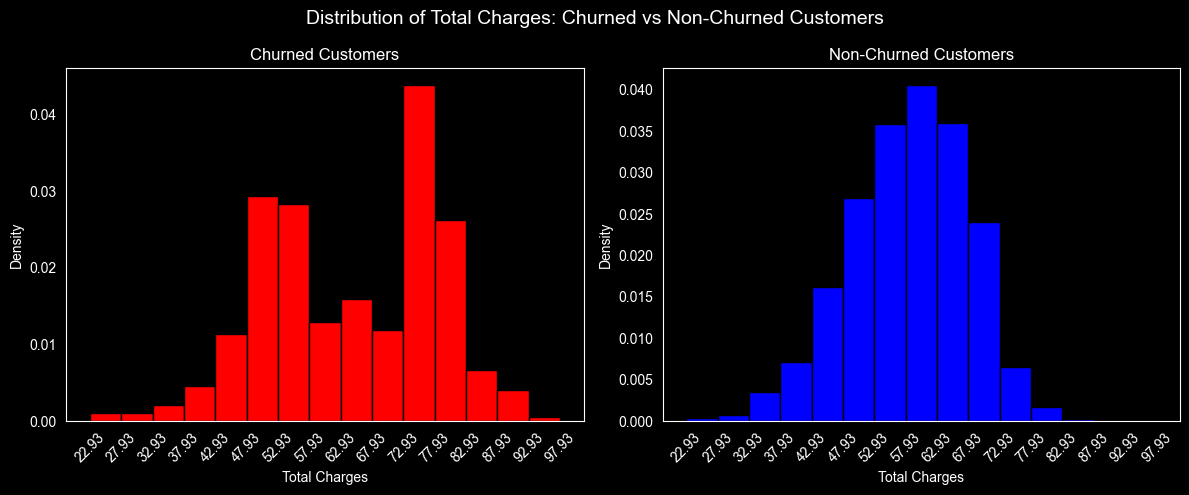

<Figure size 640x480 with 0 Axes>

In [13]:
# Define bin edges with consistent width of 5 for charge ranges
# ensures tick marks align with bar edges for readability
bins = np.arange(churned['Total charges'].min(), churned['Total charges'].max() + 5, 5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribution of total charges for churned customers
ax1.hist(churned['Total charges'], bins=bins, color='red', edgecolor='black', density=True)
ax1.set_title('Churned Customers')
ax1.set_xlabel('Total Charges')
ax1.set_ylabel('Density')
ax1.set_xticks(bins)  # align x ticks with bin edges
ax1.tick_params(axis='x', rotation=45)  # rotate labels to prevent overlap
ax1.grid(False)

# Plot distribution of total charges for non-churned customers
ax2.hist(no_churned['Total charges'], bins=bins, color='blue', edgecolor='black', density=True)
ax2.set_title('Non-Churned Customers')
ax2.set_xlabel('Total Charges')
ax2.set_ylabel('Density')
ax2.set_xticks(bins)  # align x ticks with bin edges
ax2.tick_params(axis='x', rotation=45)  # rotate labels to prevent overlap
ax2.grid(False)

plt.suptitle('Distribution of Total Charges: Churned vs Non-Churned Customers', fontsize=14)
plt.tight_layout()
plt.show()
plt.clf()

Looking at the mean and median of both groups, we can say that customers that churned are charged higher than customers that didn't churn. Customers that churned get charged 11% more than customers that didn't churn. From the distribution of total charges, churned customers are heavily concentrated in the higher charge ranges above 70, while very few non-churned customers reach that level, suggesting that customers charged above 70 are at significantly higher risk of churning.

#### Visualize Customer service calls distribution for both churned and no_churned customers

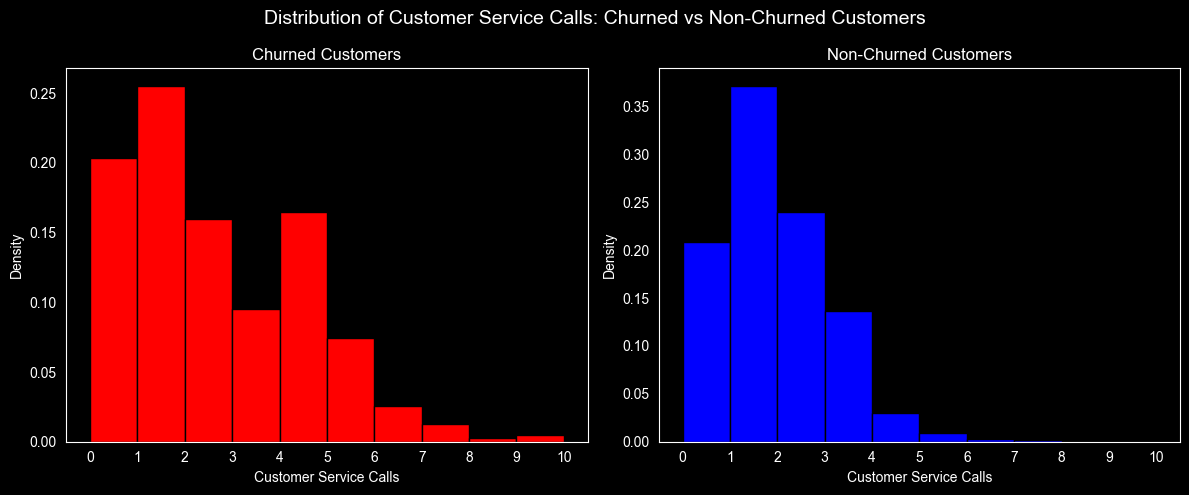

<Figure size 640x480 with 0 Axes>

In [14]:
# Define bin edges as whole numbers to align ticks with bar edges
bins = np.arange(0, churned['Customer service calls'].max() + 2, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(churned['Customer service calls'], bins=bins, color='red', edgecolor='black', density=True)
ax1.set_title('Churned Customers')
ax1.set_xlabel('Customer Service Calls')
ax1.set_ylabel('Density')
ax1.set_xticks(bins)  # align x ticks with bin edges
ax1.grid(False)

ax2.hist(no_churned['Customer service calls'], bins=bins, color='blue', edgecolor='black', density=True)
ax2.set_title('Non-Churned Customers')
ax2.set_xlabel('Customer Service Calls')
ax2.set_ylabel('Density')
ax2.set_xticks(bins)  # align x ticks with bin edges
ax2.grid(False)

plt.suptitle('Distribution of Customer Service Calls: Churned vs Non-Churned Customers', fontsize=14)
plt.tight_layout()
plt.show()
plt.clf()

Looking at the customer service distribution for both churned and non churned customers, the most frequent calls for both groups fall between one and two calls, but some churned customers have made calls that are higher than seven indicating that if a customer has more than seven customer service calls, they are more likely to churn.

#### Create two new features: total minutes(contains the total minutes used by a customer) and total calls(contains the total calls made by a customer, excluding customer service calls)

In [15]:
# Engineer total minutes and total calls features
churned['Total minutes'] = churned['Total day minutes'] + churned['Total eve minutes'] + churned['Total night minutes'] + churned['Total intl minutes']

no_churned['Total minutes'] = no_churned['Total day minutes'] + no_churned['Total eve minutes'] + no_churned['Total night minutes'] + no_churned['Total intl minutes']

churned['Total calls'] = churned['Total day calls'] + churned['Total eve calls'] + churned['Total night calls'] + churned['Total intl calls']

no_churned['Total calls'] = no_churned['Total day calls'] + no_churned['Total eve calls'] + no_churned['Total night calls'] + no_churned['Total intl calls']

In [16]:
# Compare mean and median of Total minutes between churned and non-churned customers to test hypothesis that churned customers use more minutes
print("Total Minutes: ")
print(f"Churned customers - Mean: {churned['Total minutes'].mean().round(2)}")
print(f"Churned customers - Median: {churned['Total minutes'].median().round(2)}")
print(f"\nNon-Churned customers - Mean: {no_churned['Total minutes'].mean().round(2)}")
print(f"Non-Churned customers - Median: {no_churned['Total minutes'].median().round(2)}")

# Compare mean and median of Total calls between churned and non-churned customers
# to test hypothesis that churned customers make more calls
print("\nTotal Calls:")
print(f"Churned customers - Mean: {churned['Total calls'].mean().round(2)}")
print(f"Churned customers - Median: {churned['Total calls'].median().round(2)}")
print(f"\nNon-Churned customers - Mean: {no_churned['Total calls'].mean().round(2)}")
print(f"Non-Churned customers - Median: {no_churned['Total calls'].median().round(2)}")

Total Minutes: 
Churned customers - Mean: 630.69
Churned customers - Median: 630.45

Non-Churned customers - Mean: 584.56
Non-Churned customers - Median: 590.2

Total Calls:
Churned customers - Mean: 305.88
Churned customers - Median: 306.0

Non-Churned customers - Mean: 304.74
Non-Churned customers - Median: 305.0


Churned customers on average take approximately 8% more minutes on call than non churned customers, but when it comes to the amount of calls each made, it is pretty much the same even though churned customers have a slightly higher average value. With this we can say that the amounts of minutes a customer takes on a call the more they will get charged, and this is why churned customers have 11% more charges than non churned customers.

#### Visualize total minutes distribution for both churned and no_churned customers

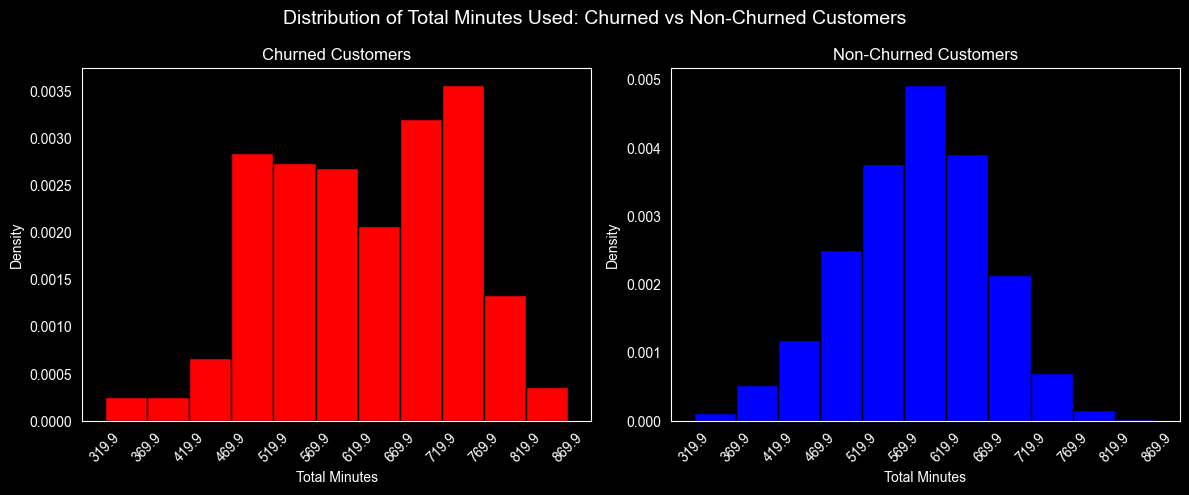

<Figure size 640x480 with 0 Axes>

In [17]:
# Define bin edges as whole numbers to align ticks with bar edges
bins = np.arange(churned['Total minutes'].min(), churned['Total minutes'].max() + 5, 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(churned['Total minutes'], bins=bins, color='red', edgecolor='black', density=True)
ax1.set_title('Churned Customers')
ax1.set_xlabel('Total Minutes')
ax1.set_ylabel('Density')
ax1.set_xticks(bins)  # align x ticks with bin edges
ax1.tick_params(axis='x', rotation=45)  # rotate labels to prevent overlap
ax1.grid(False)

ax2.hist(no_churned['Total minutes'], bins=bins, color='blue', edgecolor='black', density=True)
ax2.set_title('Non-Churned Customers')
ax2.set_xlabel('Total Minutes')
ax2.set_ylabel('Density')
ax2.set_xticks(bins)  # align x ticks with bin edges
ax2.tick_params(axis='x', rotation=45)  # rotate labels to prevent overlap
ax2.grid(False)

plt.suptitle('Distribution of Total Minutes Used: Churned vs Non-Churned Customers', fontsize=14)
plt.tight_layout()
plt.show()
plt.clf()

## What type of customers are churning and what do they have in common?
From my analysis, the type of customers that churn are customers that get charged a high amount- from what I noticed, when charges reach $70 and above, churned customers significantly outnumber non-churned customers- because they spend a lot of time on the phone. In addition to them spending a lot of time on calls, some of them have international plans which can be a factor to increased charges, and some also make a lot of customer service calls which can be because of many things, but I don't have the data to answer that question.

## Problem 2 — There's a debate internally about whether our international plan and voicemail plan are actually worth it to customers, or if they're driving people away. Can you find out?

In [24]:
"""Filter df to two new dfs called international for only customers with international plans and voicemail for only customers with voicemail plans"""
international = train[train['International plan'] == 'Yes']
voicemail = train[train['Voice mail plan'] == 'Yes']
international_voicemail = train[(train['International plan'] == 'Yes')  & (train['Voice mail plan'] == 'Yes')]

'Now you have a df with customers with international plans and another df with customers with voicemail plans. What do you do next? Find out how many customers in each df churned'

In [22]:
#Find out how many customers with an international plan churn
international['Churn'].value_counts(normalize = True)*100

Churn
False    56.296296
True     43.703704
Name: proportion, dtype: float64

In [23]:
#Find out how many customers with a voicemail plan churn
voicemail['Churn'].value_counts(normalize = True)*100

Churn
False    91.132333
True      8.867667
Name: proportion, dtype: float64

In [25]:
#Find out how many customers with both international plan and voicemail plan churn
international_voicemail['Churn'].value_counts(normalize = True)*100

Churn
False    61.333333
True     38.666667
Name: proportion, dtype: float64

43% of customers that had an international plan churned while 8% of customers that had a voicemail plan did. 38% of customers that had both plans churned which tells me that having an international plan could be driving customers away. This makes sense because in my previous analysis customers that churned are 4x more likely to hold an international plan than customers that didn't churn, and it is probably because they get charged higher cause I also found out that when charges reach $70 and above customers more likely churn than stay. I would say you should look into how much the international plan cost because nearly half the customers that have one end up leaving maybe the cost is too high for them. Another thing I noticed is that customers with a voice mail plan are significantly less likely to churn, suggesting it may be a retention factor. Yes, 38% of customers with both international and voicemail plan churned, but I believe it was due to the international plan not the voicemail plan cause only 8% of customers with a voicemail plan churned.

## Problem 3 — We think our customer service interactions might be making things worse. Can you investigate whether customers who call us more are more likely to leave?

I can answer this question by looking at how many calls they have and check how many customers leave in each group. Lets say customers with only one call check how many leave and how many stay.

In [30]:
for calls in sorted(train['Customer service calls'].unique()):
    filtered_df = train[train['Customer service calls'] == calls]
    print(f'For customers with {calls} customer service calls, this is the proportion of them that stay or leave:')
    print(filtered_df['Churn'].value_counts(normalize = True)*100)

For customers with 0 customer service calls, this is the proportion of them that stay or leave:
Churn
False    85.765766
True     14.234234
Name: proportion, dtype: float64
For customers with 1 customer service calls, this is the proportion of them that stay or leave:
Churn
False    89.52381
True     10.47619
Name: proportion, dtype: float64
For customers with 2 customer service calls, this is the proportion of them that stay or leave:
Churn
False    89.802632
True     10.197368
Name: proportion, dtype: float64
For customers with 3 customer service calls, this is the proportion of them that stay or leave:
Churn
False    89.367816
True     10.632184
Name: proportion, dtype: float64
For customers with 4 customer service calls, this is the proportion of them that stay or leave:
Churn
False    51.879699
True     48.120301
Name: proportion, dtype: float64
For customers with 5 customer service calls, this is the proportion of them that stay or leave:
Churn
True     59.183673
False    40.8163

From what I see here, customers who call more are more likely to leave, and it starts when calls reach four or more. When calls are below or equal to 3, customers that leave are below 15%, but this value jumps to nearly half when calls reach 4, and the number of customers leaving increases as the calls increases leading to 100% customers leaving when calls reach 8. I would say customers are probably dissatisfied with the service and their demands aren't met in some way. Maybe, they have been calling for a certain issue to be solved, and it still hasn't been solved. I am also very curious why the amount of people that leave jumped when they made 4 calls. However, the 100% churn rate at 8 and 9 calls should be interpreted with caution as there are very few customers in those groups, making the statistic unreliable. The most actionable threshold remains 4 calls, where churn risk jumps from below 15% to nearly 50%